# CSCI 567 — final: Temporally Robust and Fair Credit Risk Prediction
**LendingClub 2007–2018**


## 0. Setup Environment & Data Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/CSCI567/lendingclub/archive.zip" /content/
!unzip -q /content/archive.zip -d /content/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', low_memory=False)
# df = pd.read_csv(
#     '/content/drive/MyDrive/Colab Notebooks/CSCI567/accepted_2007_to_2018Q4.csv',
#     low_memory=False
# )
print(f'Raw shape: {df.shape}')

Raw shape: (2260701, 151)


In [4]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.1 MB/s eta 0:00:00


In [5]:
import subprocess
try:
    subprocess.check_output('nvidia-smi', shell=True)
    DEVICE = 'cuda'
except:
    DEVICE = 'cpu'

print(f"Device: {DEVICE}")

Device: cuda


In [6]:
import os
print(os.cpu_count())

12


## 1. Preprocessing

In [7]:
# Target Creation
default_labels = ['Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Charged Off']
df['target'] = df['loan_status'].isin(default_labels).astype(int)

# Date Parsing
df['issue_d']  = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['age_proxy'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['age_proxy']).dt.days / 365

# Feature Selection
FEATURES = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'delinq_2yrs', 'fico_range_low', 'open_acc',
            'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
            'mort_acc', 'pub_rec_bankruptcies']

# Sampling
df_sample = df.sample(n=200000, random_state=42).copy()
print(f'Sample shape: {df_sample.shape}')
print(f'Default rate: {df_sample["target"].mean():.3f}')

Sample shape: (200000, 155)
Default rate: 0.119


## 2. Data Splitting

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Temporal split: train / val / test
train_t = df_sample[df_sample['issue_year'] <= 2013].copy()
val_t   = df_sample[(df_sample['issue_year'] >= 2014) & (df_sample['issue_year'] <= 2015)].copy()
test_t  = df_sample[df_sample['issue_year'] >= 2016].copy()

# Imputation: learn medians from training splits only
temporal_fill = train_t[FEATURES + ['credit_history_years']].median()

for split_df in [train_t, val_t, test_t]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(temporal_fill)

# Fairness groups: learn cutoffs from temporal train only
credit_bins = pd.qcut(train_t['credit_history_years'], q=3, retbins=True, duplicates='drop')[1]
income_clip_top = train_t['annual_inc'].quantile(0.99)
income_bins = pd.qcut(train_t['annual_inc'].clip(upper=income_clip_top), q=3, retbins=True, duplicates='drop')[1]

credit_bins[0] = -np.inf
credit_bins[-1] = np.inf
income_bins[0] = -np.inf
income_bins[-1] = np.inf

for split_df in [train_t, val_t, test_t]:
    split_df['credit_group'] = pd.cut(split_df['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
    split_df['income_group'] = pd.cut(split_df['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)

X_train_t = train_t[FEATURES]
y_train_t = train_t['target']
X_val_t   = val_t[FEATURES]
y_val_t   = val_t['target']
X_test_t  = test_t[FEATURES]
y_test_t  = test_t['target']

# Scaling: fit each scaler on its own training split only
scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)
X_val_t_sc   = scaler_t.transform(X_val_t)
X_test_t_sc  = scaler_t.transform(X_test_t)

print('Temporal split')
print(f'  Train (<=2013):   {len(X_train_t):,}')
print(f'  Val (2014-2015):  {len(X_val_t):,}')
print(f'  Test (>=2016):    {len(X_test_t):,}')

print('\nTemporal-train fairness group distribution')
print(train_t['credit_group'].value_counts())
print(train_t['income_group'].value_counts())

print('\nYearly default count')
for yr in sorted(df_sample['issue_year'].unique()):
    sub = df_sample[df_sample['issue_year'] == yr]
    print(f'  {yr}: total={len(sub):,}  default={sub["target"].sum():,}  default_rate={sub["target"].mean():.3f}')

Temporal split
  Train (<=2013):   20,286
  Val (2014-2015):  58,114
  Test (>=2016):    121,596

Temporal-train fairness group distribution
credit_group
mid      6775
short    6764
long     6747
Name: count, dtype: int64
income_group
low     7220
high    6728
mid     6338
Name: count, dtype: int64

Yearly default count
  2007.0: total=46  default=10  default_rate=0.217
  2008.0: total=206  default=37  default_rate=0.180
  2009.0: total=488  default=66  default_rate=0.135
  2010.0: total=1,121  default=176  default_rate=0.157
  2011.0: total=1,946  default=284  default_rate=0.146
  2012.0: total=4,597  default=725  default_rate=0.158
  2013.0: total=11,882  default=1,838  default_rate=0.155
  2014.0: total=20,956  default=3,676  default_rate=0.175
  2015.0: total=37,158  default=6,797  default_rate=0.183
  2016.0: total=38,347  default=5,976  default_rate=0.156
  2017.0: total=39,269  default=3,521  default_rate=0.090
  2018.0: total=43,980  default=746  default_rate=0.017
  nan: total

In [9]:
# By year temporal test sets (AUC over time)
yearly_tests = {}
for yr in sorted(df_sample['issue_year'].unique()):
    sub = df_sample[df_sample['issue_year'] == yr].copy()
    if len(sub) > 0:
        sub[FEATURES + ['credit_history_years']] = sub[FEATURES + ['credit_history_years']].fillna(temporal_fill)
        sub['credit_group'] = pd.cut(sub['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
        sub['income_group'] = pd.cut(sub['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)
        yearly_tests[yr] = (sub[FEATURES], sub['target'], scaler_t.transform(sub[FEATURES]), sub)
        print(f'{yr}: {len(sub):,} samples, default rate={sub["target"].mean():.3f}')

2007.0: 46 samples, default rate=0.217
2008.0: 206 samples, default rate=0.180
2009.0: 488 samples, default rate=0.135
2010.0: 1,121 samples, default rate=0.157
2011.0: 1,946 samples, default rate=0.146
2012.0: 4,597 samples, default rate=0.158
2013.0: 11,882 samples, default rate=0.155
2014.0: 20,956 samples, default rate=0.175
2015.0: 37,158 samples, default rate=0.183
2016.0: 38,347 samples, default rate=0.156
2017.0: 39,269 samples, default rate=0.090
2018.0: 43,980 samples, default rate=0.017


## 3. Model Definition — Full Model + Hyperparameter Sweep


In [10]:
# Computes a robustness-penalized AUC score by subtracting the AUC fluctuation across years from the mean AUC.
# TRP(Temporally Robust Performance)
LAMBDA = 1.0
VAL_YEARS  = [2014, 2015]
TEST_YEARS = [2016, 2017, 2018]

def compute_auc_score(yearly_aucs, years, lam=LAMBDA):
    aucs = [yearly_aucs[yr] for yr in years if yr in yearly_aucs]
    if len(aucs) == 0:
        return np.nan
    auc_mean = np.mean(aucs)
    auc_drop = max(aucs) - min(aucs)
    return auc_mean - lam * auc_drop

In [11]:
# Computes FPR, TPR, PPR for each demographic group at a given threshold to measure model fairness.
def compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=0.5):
    records = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    for g in groups:
        mask = (group_col == g).values
        yt = y_true[mask]
        yp = y_pred[mask]
        ypr = y_prob[mask]

        if len(yt) == 0:
            continue

        tp = ((yp == 1) & (yt == 1)).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        tn = ((yp == 0) & (yt == 0)).sum()
        fn = ((yp == 0) & (yt == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        ppr = yp.mean()

        records.append({
            'group': g,
            'threshold': threshold,
            'FPR': fpr,
            'TPR': tpr,
            'PPR': ppr,
            'n': mask.sum(),
        })
    return pd.DataFrame(records)

In [12]:
# Sweeps across multiple thresholds and computes FPR/TPR/PPR disparity (max-min gap between groups) at each threshold.
def compute_threshold_sweep(y_true, y_prob, groups, group_col, thresholds):
    records = []
    for thr in thresholds:
        df_thr = compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=thr)
        if len(df_thr) == 0:
            continue
        records.append({
            'threshold': thr,
            'FPR_disp': df_thr['FPR'].max() - df_thr['FPR'].min(),
            'TPR_disp': df_thr['TPR'].max() - df_thr['TPR'].min(),
            'PPR_disp': df_thr['PPR'].max() - df_thr['PPR'].min(),
        })
    return pd.DataFrame(records)

In [13]:
# Trains and evaluates multiple model configs, computing AUC, F1, accuracy, and yearly AUC robustness scores for each model.
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
from sklearn.metrics import recall_score, f1_score, precision_score
import time

def evaluate_model_configs(model_configs):
    eval_results = {}
    for name, (model, input_type) in model_configs.items():
        t0 = time.time()
        temporal_model = clone(model)

        if input_type == 'scaled':
            Xtr_t, Xva_t, Xte_t = X_train_t_sc, X_val_t_sc, X_test_t_sc
        else:
            Xtr_t, Xva_t, Xte_t = X_train_t, X_val_t, X_test_t

        temporal_model.fit(Xtr_t, y_train_t)

        y_prob_t_val = temporal_model.predict_proba(Xva_t)[:, 1]
        y_prob_t = temporal_model.predict_proba(Xte_t)[:, 1]

        # val set optimal threshold
        thresholds = np.arange(0.05, 0.50, 0.01)
        best_thr_t = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_t_val >= t).astype(int), zero_division=0))

        # apply threshold
        y_pred_t_val = (y_prob_t_val >= best_thr_t).astype(int)
        y_pred_t = (y_prob_t >= best_thr_t).astype(int)

        eval_results[name] = {
            'temporal': {
                'val_y_prob': y_prob_t_val,
                'val_y_pred': y_pred_t_val,
                'val_auc': roc_auc_score(y_val_t, y_prob_t_val),
                'val_acc': accuracy_score(y_val_t, y_pred_t_val),
                'val_brier': brier_score_loss(y_val_t, y_prob_t_val),
                'val_recall': recall_score(y_val_t, y_pred_t_val, zero_division=0),
                'val_precision': precision_score(y_val_t, y_pred_t_val, zero_division=0),
                'val_f1': f1_score(y_val_t, y_pred_t_val, zero_division=0),
                'y_pred': y_pred_t,
                'y_prob': y_prob_t,
                'auc': roc_auc_score(y_test_t, y_prob_t),
                'acc': accuracy_score(y_test_t, y_pred_t),
                'brier': brier_score_loss(y_test_t, y_prob_t),
                'recall': recall_score(y_test_t, y_pred_t, zero_division=0),
                'precision': precision_score(y_test_t, y_pred_t, zero_division=0),
                'f1': f1_score(y_test_t, y_pred_t, zero_division=0),
                'threshold': best_thr_t,
                'model': temporal_model,
            },
            'yearly': {}
        }

        for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
            X_in = X_yr_sc if input_type == 'scaled' else X_yr
            yp = temporal_model.predict_proba(X_in)[:, 1]
            eval_results[name]['yearly'][yr] = roc_auc_score(y_yr, yp)

        yearly_aucs = eval_results[name]['yearly']
        eval_results[name]['auc_drop'] = compute_auc_score(yearly_aucs, TEST_YEARS)
        eval_results[name]['val_auc_drop'] = compute_auc_score(yearly_aucs, VAL_YEARS)

    return eval_results

In [14]:
def print_selection_table(eval_results, sort_key='val_auc', reverse=True, title=None, mode='val'):
    if title:
        print(f'\n=== {title} ===')

    if mode == 'val':
        key_fn = {
            'val_auc': lambda x: x[1]['temporal']['val_auc'],
            'val_auc_drop': lambda x: x[1]['val_auc_drop'],
            'val_recall': lambda x: x[1]['temporal']['val_recall'],
            'val_precision': lambda x: x[1]['temporal']['val_precision'],
            'val_f1': lambda x: x[1]['temporal']['val_f1'],
        }.get(sort_key, lambda x: x[1]['temporal']['val_auc'])

        for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
            print(f"{name:20s}  "
                  f"temp_val_AUC={res['temporal']['val_auc']:.4f}  "
                  f"val_AUC_drop={res['val_auc_drop']:.4f}  "
                  f"val_Recall={res['temporal']['val_recall']:.4f}  "
                  f"val_Precision={res['temporal']['val_precision']:.4f}  "
                  f"val_F1={res['temporal']['val_f1']:.4f}  "
                  f"threshold={res['temporal']['threshold']:.2f}")

    elif mode == 'test':
        key_fn = {
            'test_auc': lambda x: x[1]['temporal']['auc'],
            'test_auc_drop': lambda x: x[1]['auc_drop'],
            'recall': lambda x: x[1]['temporal']['recall'],
            'precision': lambda x: x[1]['temporal']['precision'],
            'f1': lambda x: x[1]['temporal']['f1'],
        }.get(sort_key, lambda x: x[1]['temporal']['auc'])

        for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
            print(f"{name:20s}  "
                  f"temp_test_AUC={res['temporal']['auc']:.4f}  "
                  f"test_AUC_drop={res['auc_drop']:.4f}  "
                  f"Recall={res['temporal']['recall']:.4f}  "
                  f"Precision={res['temporal']['precision']:.4f}  "
                  f"F1={res['temporal']['f1']:.4f}  "
                  f"threshold={res['temporal']['threshold']:.2f}")

In [15]:
def print_best_summary(eval_results, prefix=None, title=None):
    filtered = {k: v for k, v in eval_results.items()
                if (k.startswith(prefix) if prefix else True)}

    best_tss = max(filtered.items(), key=lambda x: x[1]['val_auc_drop'])
    best_f1  = max(filtered.items(), key=lambda x: x[1]['temporal']['val_f1'])

    if title:
        print(f'=== {title} ===')

    print(f"\n★ Best by TSS (robust+val): {best_tss[0]}")
    print(f"   val_TSS={best_tss[1]['val_auc_drop']:.4f}  val_AUC={best_tss[1]['temporal']['val_auc']:.4f}  val_F1={best_tss[1]['temporal']['val_f1']:.4f}")

    print(f"\n★ Best by val F1:           {best_f1[0]}")
    print(f"   val_TSS={best_f1[1]['val_auc_drop']:.4f}  val_AUC={best_f1[1]['temporal']['val_auc']:.4f}  val_F1={best_f1[1]['temporal']['val_f1']:.4f}")

In [16]:
def print_optuna_results(study, top_trials, title='Optuna Results'):
    print(f'\n=== {title} ===')
    print(f'Best score: {study.best_value:.4f}')
    print(f'\nBest params:')
    for k, v in study.best_params.items():
        print(f'  {k:20s}: {v}')

    print(f'\n=== Top {len(top_trials)} Trials ===')
    for i, t in enumerate(top_trials):
        print(f'\n[{i+1}] score={t.value:.4f}')
        for k, v in t.params.items():
            print(f'  {k:20s}: {v}')

## 3.1 XGBoost Test Code (Find Best)


In [17]:
import optuna
from optuna.samplers import TPESampler

w_f1 = 0
w_trp = 1

## 3.1.1 XGBoost Grid Search


## 3.1.2 XGBoost Bayesian Search

In [18]:
# Optuna hyperparameter tuning for XGBoost, optimizing a weighted combination of AUC robustness score and F1 over 60 trials.
# Manual search
from xgboost import XGBClassifier
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 4),
        'subsample': trial.suggest_float('subsample', 0.6, 0.85),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 3.0),
    }

    model = XGBClassifier(**params, eval_metric='logloss', random_state=42, device=DEVICE)
    model.fit(X_train_t_sc, y_train_t)

    yearly_aucs = {}
    for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
        yp = model.predict_proba(X_yr_sc)[:, 1]
        yearly_aucs[yr] = roc_auc_score(y_yr, yp)

    val_trp = compute_auc_score(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_trp * val_trp + w_f1 * val_f1

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=True)

[I 2026-05-10 09:55:19,083] A new study created in memory with name: no-name-b0663f8b-0c90-4a0f-af29-740c41a93eab


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-10 09:55:20,530] Trial 0 finished with value: 0.6670559501728407 and parameters: {'n_estimators': 87, 'learning_rate': 0.046187109390049115, 'max_depth': 4, 'subsample': 0.7496646210492591, 'gamma': 0.7800932022121826, 'reg_lambda': 1.3119890406724053}. Best is trial 0 with value: 0.6670559501728407.
[I 2026-05-10 09:55:20,933] Trial 1 finished with value: 0.6652439505865414 and parameters: {'n_estimators': 55, 'learning_rate': 0.04031170288036924, 'max_depth': 4, 'subsample': 0.7770181444490114, 'gamma': 0.10292247147901223, 'reg_lambda': 2.9398197043239884}. Best is trial 0 with value: 0.6670559501728407.
[I 2026-05-10 09:55:21,406] Trial 2 finished with value: 0.6650390201831525 and parameters: {'n_estimators': 134, 'learning_rate': 0.014074036373847479, 'max_depth': 3, 'subsample': 0.6458511274633585, 'gamma': 1.5212112147976886, 'reg_lambda': 2.049512863264476}. Best is trial 0 with value: 0.6670559501728407.
[I 2026-05-10 09:55:21,852] Trial 3 finished with value: 0.66

In [19]:
import optuna.visualization as vis

import optuna.visualization as vis

# 1. Hyperparameter Importance
# Identifies which hyperparameters had the most significant impact on the objective score (Weighted AUC Robustness + F1).
# Useful for justifying the selection of key tuning variables in your thesis.
fig1 = vis.plot_param_importances(study_xgb)
fig1.show()

# 2. Optimization History
# Visualizes the progress of the trials to determine if the objective value has converged.
# Helps in deciding whether additional trials are necessary for further improvement.
fig2 = vis.plot_optimization_history(study_xgb)
fig2.show()

# 3. Contour Plot (Parameter Interactions)
# Illustrates the interaction between specific parameters (e.g., learning_rate vs. reg_lambda).
# Identifies the "high-performance regions" within the 2D search space.
fig3 = vis.plot_contour(study_xgb, params=['learning_rate', 'reg_lambda'])
fig3.show()

# 4. Parallel Coordinate Plot
# Displays the multi-dimensional relationships between all hyperparameters and the objective value.
# Provides a holistic view of the "paths" that lead to high-scoring configurations.
fig4 = vis.plot_parallel_coordinate(study_xgb)
fig4.show()

# 5. Slice Plot (Individual Parameter Relationships)
# Shows the distribution of the objective score for each hyperparameter's values.
# Helps identify the optimal range and sensitivity for each individual parameter.
fig5 = vis.plot_slice(study_xgb)
fig5.show()

In [20]:
# Extracts best Optuna trials
# best manual search
trials_df = study_xgb.trials_dataframe().sort_values('value', ascending=False).head(5)

XGB_MODEL_CONFIGS = {}
for i, row in enumerate(study_xgb.trials):
    if i >= 10:
        break
top_trials = sorted(study_xgb.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]

for i, t in enumerate(top_trials):
    name = f'XGB_optuna_{i+1}'
    XGB_MODEL_CONFIGS[name] = (
        XGBClassifier(**t.params, eval_metric='logloss', random_state=42), 'raw'
    )

# evaluation
xgb_results = evaluate_model_configs(XGB_MODEL_CONFIGS)

# val set
print_selection_table(xgb_results, sort_key='val_auc', reverse=True, title='XGB - Val Temperal AUC', mode='val')
print_selection_table(xgb_results, sort_key='val_auc_drop', reverse=True, title='XGB - Val Robustness TRP', mode='val')
print_selection_table(xgb_results, sort_key='val_f1', reverse=True, title='XGB - Val F1', mode='val')

# best summary
print_best_summary(xgb_results, prefix='XGB_', title='XGBoost Selection Summary')

# Hyperparameter print
print_optuna_results(study_xgb, top_trials, title='XGB Optuna Hyperparameter Results')


=== XGB - Val Temperal AUC ===
XGB_optuna_2          temp_val_AUC=0.6832  val_AUC_drop=0.6684  val_Recall=0.5909  val_Precision=0.2820  val_F1=0.3818  threshold=0.16
XGB_optuna_5          temp_val_AUC=0.6830  val_AUC_drop=0.6689  val_Recall=0.5871  val_Precision=0.2822  val_F1=0.3812  threshold=0.16
XGB_optuna_4          temp_val_AUC=0.6828  val_AUC_drop=0.6686  val_Recall=0.5896  val_Precision=0.2807  val_F1=0.3803  threshold=0.16
XGB_optuna_3          temp_val_AUC=0.6826  val_AUC_drop=0.6686  val_Recall=0.5862  val_Precision=0.2812  val_F1=0.3801  threshold=0.16
XGB_optuna_1          temp_val_AUC=0.6817  val_AUC_drop=0.6677  val_Recall=0.5857  val_Precision=0.2811  val_F1=0.3799  threshold=0.16

=== XGB - Val Robustness TRP ===
XGB_optuna_5          temp_val_AUC=0.6830  val_AUC_drop=0.6689  val_Recall=0.5871  val_Precision=0.2822  val_F1=0.3812  threshold=0.16
XGB_optuna_4          temp_val_AUC=0.6828  val_AUC_drop=0.6686  val_Recall=0.5896  val_Precision=0.2807  val_F1=0.3803  thre

## 3.2 Logistic Regression Test Code (Find Best)


## 3.2.1 LR Gird Search

## 3.2.2 LR Bayesian Search

In [21]:
# Optuna hyperparameter tuning for Logistic Regression, optimizing penalty type (L1/L2/ElasticNet), C, and l1_ratio over 40 trials.
from sklearn.linear_model import LogisticRegression
def objective_lr(trial):
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    C = trial.suggest_float('C', 1e-4, 1e-2, log=True)

    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.05, 0.3)
        solver = 'saga'
    elif penalty == 'l1':
        l1_ratio = None
        solver = 'liblinear'
    else:
        l1_ratio = None
        solver = 'liblinear'

    kwargs = dict(C=C, penalty=penalty, solver=solver, class_weight='balanced', max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio

    model = LogisticRegression(**kwargs)
    model.fit(X_train_t_sc, y_train_t)

    yearly_aucs = {}
    for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
        yp = model.predict_proba(X_yr_sc)[:, 1]
        yearly_aucs[yr] = roc_auc_score(y_yr, yp)

    val_trp = compute_auc_score(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_trp * val_trp + w_f1 * val_f1
study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=40, show_progress_bar=True)

[I 2026-05-10 09:55:58,116] A new study created in memory with name: no-name-9c3a1da7-0e53-439f-b3ac-d3cc621c91f1


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-10 09:55:58,484] Trial 0 finished with value: 0.65404018890073 and parameters: {'penalty': 'l1', 'C': 0.0015751320499779737}. Best is trial 0 with value: 0.65404018890073.
[I 2026-05-10 09:55:58,871] Trial 1 finished with value: 0.667791211439344 and parameters: {'penalty': 'l2', 'C': 0.005399484409787433}. Best is trial 1 with value: 0.667791211439344.
[I 2026-05-10 09:55:59,252] Trial 2 finished with value: 0.6620987845284612 and parameters: {'penalty': 'l1', 'C': 0.008706020878304856}. Best is trial 1 with value: 0.667791211439344.
[I 2026-05-10 09:55:59,631] Trial 3 finished with value: 0.6626706492681677 and parameters: {'penalty': 'l2', 'C': 0.00023270677083837802}. Best is trial 1 with value: 0.667791211439344.
[I 2026-05-10 09:55:59,966] Trial 4 finished with value: 0.6518521606463475 and parameters: {'penalty': 'l1', 'C': 0.0003823475224675188}. Best is trial 1 with value: 0.667791211439344.
[I 2026-05-10 09:56:00,346] Trial 5 finished with value: 0.6645082129499158

In [22]:
# best
top_trials_lr = sorted(study_lr.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]

LR_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_lr):
    name = f'LR_optuna_{i+1}'
    params = t.params.copy()
    penalty  = params.pop('penalty')
    C        = params.pop('C')
    l1_ratio = params.pop('l1_ratio', None)
    solver   = 'saga' if penalty == 'elasticnet' else 'liblinear'

    kwargs = dict(C=C, penalty=penalty, solver=solver, max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio

    LR_MODEL_CONFIGS[name] = (LogisticRegression(**kwargs), 'scaled')

# evaluation
lr_results = evaluate_model_configs(LR_MODEL_CONFIGS)

# val set
print_selection_table(lr_results, sort_key='val_auc', reverse=True, title='LR - Val Temperal AUC', mode='val')
print_selection_table(lr_results, sort_key='val_auc_drop', reverse=True, title='LR - Val Robustness TRP', mode='val')
print_selection_table(lr_results, sort_key='val_f1', reverse=True, title='LR - Val F1', mode='val')

# best summary
print_best_summary(lr_results, prefix='LR_', title='Logistic Regression Selection Summary')

# Hyperparameter print
print_optuna_results(study_lr, top_trials_lr, title='LR Optuna Hyperparameter Results')


=== LR - Val Temperal AUC ===
LR_optuna_5           temp_val_AUC=0.6832  val_AUC_drop=0.6667  val_Recall=0.6358  val_Precision=0.2723  val_F1=0.3813  threshold=0.15
LR_optuna_4           temp_val_AUC=0.6832  val_AUC_drop=0.6668  val_Recall=0.6357  val_Precision=0.2719  val_F1=0.3809  threshold=0.15
LR_optuna_3           temp_val_AUC=0.6830  val_AUC_drop=0.6673  val_Recall=0.5863  val_Precision=0.2822  val_F1=0.3810  threshold=0.16
LR_optuna_2           temp_val_AUC=0.6830  val_AUC_drop=0.6673  val_Recall=0.5867  val_Precision=0.2818  val_F1=0.3807  threshold=0.16
LR_optuna_1           temp_val_AUC=0.6829  val_AUC_drop=0.6676  val_Recall=0.6423  val_Precision=0.2703  val_F1=0.3805  threshold=0.15

=== LR - Val Robustness TRP ===
LR_optuna_1           temp_val_AUC=0.6829  val_AUC_drop=0.6676  val_Recall=0.6423  val_Precision=0.2703  val_F1=0.3805  threshold=0.15
LR_optuna_2           temp_val_AUC=0.6830  val_AUC_drop=0.6673  val_Recall=0.5867  val_Precision=0.2818  val_F1=0.3807  thresh

## 3.3 Decision Tree Test Code (Find Best)


## 3.2.1 DT Grid Search

## 3.2.2 DT Bayesian Search

In [23]:
# Optuna hyperparameter tuning for Decision Tree, optimizing TRP over 60 trials by searching
# max_depth, min_samples_leaf, min_samples_split, and criterion.
from sklearn.tree import DecisionTreeClassifier
def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train_t_sc, y_train_t)

    yearly_aucs = {}
    for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
        yp = model.predict_proba(X_yr_sc)[:, 1]
        yearly_aucs[yr] = roc_auc_score(y_yr, yp)
    val_trp = compute_auc_score(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_trp * val_trp + w_f1 * val_f1
study_dt = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=40, show_progress_bar=True)

[I 2026-05-10 09:56:32,608] A new study created in memory with name: no-name-e9dc1bf9-b1cf-438a-b87d-a9f982ae11da


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-10 09:56:33,006] Trial 0 finished with value: 0.6528644825192002 and parameters: {'max_depth': 4, 'min_samples_leaf': 48, 'min_samples_split': 37, 'criterion': 'gini'}. Best is trial 0 with value: 0.6528644825192002.
[I 2026-05-10 09:56:33,351] Trial 1 finished with value: 0.6479568233510747 and parameters: {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 44, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6528644825192002.
[I 2026-05-10 09:56:33,691] Trial 2 finished with value: 0.6449843904482843 and parameters: {'max_depth': 3, 'min_samples_leaf': 49, 'min_samples_split': 42, 'criterion': 'gini'}. Best is trial 0 with value: 0.6528644825192002.
[I 2026-05-10 09:56:34,027] Trial 3 finished with value: 0.6449843904482843 and parameters: {'max_depth': 3, 'min_samples_leaf': 16, 'min_samples_split': 27, 'criterion': 'gini'}. Best is trial 0 with value: 0.6528644825192002.
[I 2026-05-10 09:56:34,394] Trial 4 finished with value: 0.6502351574552659 and parame

In [24]:
# best
top_trials_dt = sorted(study_dt.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]

DT_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_dt):
    name = f'DTree_optuna_{i+1}'
    DT_MODEL_CONFIGS[name] = (
        DecisionTreeClassifier(**t.params, random_state=42), 'raw'
    )

# evaluation
dt_results = evaluate_model_configs(DT_MODEL_CONFIGS)

# val set
print_selection_table(dt_results, sort_key='val_auc', reverse=True, title='DT - Val Temperal AUC', mode='val')
print_selection_table(dt_results, sort_key='val_auc_drop', reverse=True, title='DT - Val Robustness TRP', mode='val')
print_selection_table(dt_results, sort_key='val_f1', reverse=True, title='DT - Val F1', mode='val')

# best summary
print_best_summary(dt_results, prefix='DTree_', title='Decision Tree Selection Summary')

# Hyperparameter print
print_optuna_results(study_dt, top_trials_dt, title='DT Optuna Hyperparameter Results')


=== DT - Val Temperal AUC ===
DTree_optuna_1        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  threshold=0.13
DTree_optuna_2        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  threshold=0.13
DTree_optuna_3        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  threshold=0.13
DTree_optuna_4        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  threshold=0.13
DTree_optuna_5        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  threshold=0.13

=== DT - Val Robustness TRP ===
DTree_optuna_1        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  threshold=0.13
DTree_optuna_2        temp_val_AUC=0.6719  val_AUC_drop=0.6529  val_Recall=0.6146  val_Precision=0.2664  val_F1=0.3717  thresh

## 3.4 Random Forest Test Code (Find Best)


## 3.4.1 RF Grid Search

## 3.4.2 RF Bayesian Search

In [25]:
# Optuna hyperparameter tuning for Random Forest,
# optimizing TRP over 50 trials by searching n_estimators, max_depth, min_samples_leaf, and max_features.
from sklearn.ensemble import RandomForestClassifier
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.5]),
    }

    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_t_sc, y_train_t)

    yearly_aucs = {}
    for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
        yp = model.predict_proba(X_yr_sc)[:, 1]
        yearly_aucs[yr] = roc_auc_score(y_yr, yp)
    val_trp = compute_auc_score(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_trp * val_trp + w_f1 * val_f1
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=40, show_progress_bar=True)

[I 2026-05-10 09:56:49,541] A new study created in memory with name: no-name-8f2f2f07-4690-4147-a2b0-5783eb28ca6d


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-10 09:56:50,688] Trial 0 finished with value: 0.6659060345915709 and parameters: {'n_estimators': 106, 'max_depth': 5, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6659060345915709.
[I 2026-05-10 09:56:51,623] Trial 1 finished with value: 0.662954139925996 and parameters: {'n_estimators': 73, 'max_depth': 3, 'min_samples_leaf': 18, 'max_features': 0.5}. Best is trial 0 with value: 0.6659060345915709.
[I 2026-05-10 09:56:52,406] Trial 2 finished with value: 0.6672068679752495 and parameters: {'n_estimators': 53, 'max_depth': 5, 'min_samples_leaf': 17, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6672068679752495.
[I 2026-05-10 09:56:53,297] Trial 3 finished with value: 0.6598356083319035 and parameters: {'n_estimators': 77, 'max_depth': 3, 'min_samples_leaf': 11, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6672068679752495.
[I 2026-05-10 09:56:54,705] Trial 4 finished with value: 0.6634674748570196 and parameters: {'n_est

In [26]:
# best
top_trials_rf = sorted(study_rf.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]

RF_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_rf):
    name = f'RF_optuna_{i+1}'
    RF_MODEL_CONFIGS[name] = (
        RandomForestClassifier(**t.params, random_state=42, n_jobs=-1), 'raw'
    )

# evaluation
rf_results = evaluate_model_configs(RF_MODEL_CONFIGS)

# val set
print_selection_table(rf_results, sort_key='val_auc', reverse=True, title='RF - Val Temperal AUC', mode='val')
print_selection_table(rf_results, sort_key='val_auc_drop', reverse=True, title='RF - Val Robustness TRP', mode='val')
print_selection_table(rf_results, sort_key='val_f1', reverse=True, title='RF - Val F1', mode='val')

# best summary
print_best_summary(rf_results, prefix='RF_', title='Random Forest Selection Summary')

# Hyperparameter print
print_optuna_results(study_rf, top_trials_rf, title='RF Optuna Hyperparameter Results')


=== RF - Val Temperal AUC ===
RF_optuna_3           temp_val_AUC=0.6813  val_AUC_drop=0.6673  val_Recall=0.6021  val_Precision=0.2773  val_F1=0.3797  threshold=0.15
RF_optuna_4           temp_val_AUC=0.6813  val_AUC_drop=0.6673  val_Recall=0.6021  val_Precision=0.2773  val_F1=0.3797  threshold=0.15
RF_optuna_5           temp_val_AUC=0.6812  val_AUC_drop=0.6672  val_Recall=0.6047  val_Precision=0.2764  val_F1=0.3794  threshold=0.15
RF_optuna_2           temp_val_AUC=0.6805  val_AUC_drop=0.6673  val_Recall=0.6057  val_Precision=0.2756  val_F1=0.3788  threshold=0.15
RF_optuna_1           temp_val_AUC=0.6801  val_AUC_drop=0.6677  val_Recall=0.6114  val_Precision=0.2741  val_F1=0.3785  threshold=0.15

=== RF - Val Robustness TRP ===
RF_optuna_1           temp_val_AUC=0.6801  val_AUC_drop=0.6677  val_Recall=0.6114  val_Precision=0.2741  val_F1=0.3785  threshold=0.15
RF_optuna_2           temp_val_AUC=0.6805  val_AUC_drop=0.6673  val_Recall=0.6057  val_Precision=0.2756  val_F1=0.3788  thresh

## 3.5.1 NN Grid Search

## 3.5.2 NN Bayesian Search

In [27]:
# Optuna hyperparameter tuning for MLP, optimizing TRP over 60 trials
# by searching hidden_layer_sizes, alpha, and learning_rate_init.
from sklearn.neural_network import MLPClassifier
def objective_nn(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
            [(128,), (128, 64), (128, 64, 32)]),
        'alpha': trial.suggest_float('alpha', 1e-4, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'max_iter': 200,
        'early_stopping': True,
        'random_state': 42,
    }

    model = MLPClassifier(**params)
    model.fit(X_train_t_sc, y_train_t)

    yearly_aucs = {}
    for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
        yp = model.predict_proba(X_yr_sc)[:, 1]
        yearly_aucs[yr] = roc_auc_score(y_yr, yp)
    val_trp = compute_auc_score(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_trp * val_trp + w_f1 * val_f1

study_nn = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_nn.optimize(objective_nn, n_trials=60, show_progress_bar=True)

[I 2026-05-10 09:57:37,415] A new study created in memory with name: no-name-57c8f310-d137-4a47-8f27-3a962fbee703


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-10 09:57:39,921] Trial 0 finished with value: 0.5377468947684104 and parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 0.006251373574521752, 'learning_rate_init': 0.0002051338263087451}. Best is trial 0 with value: 0.5377468947684104.
[I 2026-05-10 09:57:44,557] Trial 1 finished with value: 0.66615418304258 and parameters: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.006358358856676255, 'learning_rate_init': 0.0026070247583707684}. Best is trial 1 with value: 0.66615418304258.
[I 2026-05-10 09:57:47,666] Trial 2 finished with value: 0.5499996708833392 and parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0004335281794951569, 'learning_rate_init': 0.0002310201887845295}. Best is trial 1 with value: 0.66615418304258.
[I 2026-05-10 09:57:52,086] Trial 3 finished with value: 0.6699086685039323 and parameters: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0019762189340280074, 'learning_rate_init': 0.0003823475224675188}. Best is trial 3 with value: 0.6699086685

In [28]:
# best
top_trials_nn = sorted(study_nn.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]

NN_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_nn):
    name = f'NN_optuna_{i+1}'
    NN_MODEL_CONFIGS[name] = (MLPClassifier(**t.params, max_iter=200, early_stopping=True, random_state=42), 'scaled')

# evaluation
nn_results = evaluate_model_configs(NN_MODEL_CONFIGS)

# val set
print_selection_table(nn_results, sort_key='val_auc', reverse=True, title='NN - Val Temperal AUC', mode='val')
print_selection_table(nn_results, sort_key='val_auc_drop', reverse=True, title='NN - Val Robustness TRP', mode='val')
print_selection_table(nn_results, sort_key='val_f1', reverse=True, title='NN - Val F1', mode='val')

# best summary
print_best_summary(nn_results, prefix='NN_', title='Neural Network Selection Summary')

# Hyperparameter print
print_optuna_results(study_nn, top_trials_nn, title='NN Optuna Hyperparameter Results')


=== NN - Val Temperal AUC ===
NN_optuna_1           temp_val_AUC=0.6823  val_AUC_drop=0.6700  val_Recall=0.5716  val_Precision=0.2870  val_F1=0.3821  threshold=0.17
NN_optuna_3           temp_val_AUC=0.6816  val_AUC_drop=0.6699  val_Recall=0.6151  val_Precision=0.2762  val_F1=0.3812  threshold=0.16
NN_optuna_4           temp_val_AUC=0.6813  val_AUC_drop=0.6699  val_Recall=0.5771  val_Precision=0.2847  val_F1=0.3813  threshold=0.17
NN_optuna_2           temp_val_AUC=0.6812  val_AUC_drop=0.6700  val_Recall=0.5783  val_Precision=0.2842  val_F1=0.3811  threshold=0.17
NN_optuna_5           temp_val_AUC=0.6810  val_AUC_drop=0.6698  val_Recall=0.5822  val_Precision=0.2835  val_F1=0.3813  threshold=0.17

=== NN - Val Robustness TRP ===
NN_optuna_1           temp_val_AUC=0.6823  val_AUC_drop=0.6700  val_Recall=0.5716  val_Precision=0.2870  val_F1=0.3821  threshold=0.17
NN_optuna_2           temp_val_AUC=0.6812  val_AUC_drop=0.6700  val_Recall=0.5783  val_Precision=0.2842  val_F1=0.3811  thresh

## 3.6.1 LGBM Grid Search

## 3.6.2 LGBM Bayesian Search

In [29]:
# Optuna hyperparameter tuning for LightGBM, optimizing TRP over 50 trials by searching
# n_estimators, learning_rate, max_depth, num_leaves, subsample, and regularization terms.
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
    }

    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train_t_sc, y_train_t)

    yearly_aucs = {}
    for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
        yp = model.predict_proba(X_yr_sc)[:, 1]
        yearly_aucs[yr] = roc_auc_score(y_yr, yp)
    val_trp = compute_auc_score(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(X_val_t_sc)[:, 1]
    thresholds = np.arange(0.05, 0.50, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t, (y_prob_val >= t).astype(int), zero_division=0))
    val_f1 = f1_score(y_val_t, (y_prob_val >= best_thr).astype(int), zero_division=0)

    return w_trp * val_trp + w_f1 * val_f1

study_lgbm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=70, show_progress_bar=True)

[I 2026-05-10 10:01:28,732] A new study created in memory with name: no-name-0a9aaf0a-b6dc-4f53-85ed-57e82d66ef7b


  0%|          | 0/70 [00:00<?, ?it/s]

[I 2026-05-10 10:01:29,446] Trial 0 finished with value: 0.6641893747201649 and parameters: {'n_estimators': 106, 'learning_rate': 0.046187109390049115, 'max_depth': 5, 'num_leaves': 44, 'subsample': 0.6468055921327309, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.17425083650459838}. Best is trial 0 with value: 0.6641893747201649.
[I 2026-05-10 10:01:30,284] Trial 1 finished with value: 0.667572821721803 and parameters: {'n_estimators': 180, 'learning_rate': 0.026312454510574512, 'max_depth': 5, 'num_leaves': 16, 'subsample': 0.8909729556485984, 'reg_alpha': 0.8324426408004217, 'reg_lambda': 0.6370173320348285}. Best is trial 1 with value: 0.667572821721803.
[I 2026-05-10 10:01:30,730] Trial 2 finished with value: 0.6622384218771458 and parameters: {'n_estimators': 77, 'learning_rate': 0.013433656868034296, 'max_depth': 3, 'num_leaves': 40, 'subsample': 0.7295835055926347, 'reg_alpha': 0.2912291401980419, 'reg_lambda': 1.8355586841671383}. Best is trial 1 with value: 0.66757282172

In [30]:
# best
top_trials_lgbm = sorted(study_lgbm.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]

LGBM_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_lgbm):
    name = f'LGBM_optuna_{i+1}'
    LGBM_MODEL_CONFIGS[name] = (
        LGBMClassifier(**t.params, random_state=42, verbose=-1), 'raw'
    )

# evaluation
lgbm_results = evaluate_model_configs(LGBM_MODEL_CONFIGS)

# val set
print_selection_table(lgbm_results, sort_key='val_auc', reverse=True, title='LGBM - Val Temperal AUC', mode='val')
print_selection_table(lgbm_results, sort_key='val_auc_drop', reverse=True, title='LGBM - Val Robustness TRP', mode='val')
print_selection_table(lgbm_results, sort_key='val_f1', reverse=True, title='LGBM - Val F1', mode='val')

# best summary
print_best_summary(lgbm_results, prefix='LGBM_', title='LightGBM Selection Summary')

# Hyperparameter print
print_optuna_results(study_lgbm, top_trials_lgbm, title='LGBM Optuna Hyperparameter Results')


=== LGBM - Val Temperal AUC ===
LGBM_optuna_2         temp_val_AUC=0.6817  val_AUC_drop=0.6683  val_Recall=0.5945  val_Precision=0.2793  val_F1=0.3800  threshold=0.16
LGBM_optuna_5         temp_val_AUC=0.6816  val_AUC_drop=0.6676  val_Recall=0.5931  val_Precision=0.2792  val_F1=0.3796  threshold=0.16
LGBM_optuna_3         temp_val_AUC=0.6815  val_AUC_drop=0.6676  val_Recall=0.5936  val_Precision=0.2794  val_F1=0.3800  threshold=0.16
LGBM_optuna_4         temp_val_AUC=0.6815  val_AUC_drop=0.6679  val_Recall=0.5950  val_Precision=0.2786  val_F1=0.3795  threshold=0.16
LGBM_optuna_1         temp_val_AUC=0.6810  val_AUC_drop=0.6676  val_Recall=0.5518  val_Precision=0.2884  val_F1=0.3789  threshold=0.17

=== LGBM - Val Robustness TRP ===
LGBM_optuna_2         temp_val_AUC=0.6817  val_AUC_drop=0.6683  val_Recall=0.5945  val_Precision=0.2793  val_F1=0.3800  threshold=0.16
LGBM_optuna_4         temp_val_AUC=0.6815  val_AUC_drop=0.6679  val_Recall=0.5950  val_Precision=0.2786  val_F1=0.3795  th

## 4. Training & Temporal / Random AUC calculation


In [31]:
all_results = {}
all_results.update(xgb_results)
all_results.update(lr_results)
all_results.update(dt_results)
all_results.update(rf_results)
all_results.update(nn_results)
all_results.update(lgbm_results)
print(f'Total combined model configs: {len(all_results)}')

Total combined model configs: 30


In [32]:
# (val set)
print_selection_table(all_results, sort_key='val_auc', reverse=True, title='All Models - Val Temperal AUC', mode='val')
print_selection_table(all_results, sort_key='val_auc_drop', reverse=True, title='All Models - Val Robustness TRP', mode='val')
print_selection_table(all_results, sort_key='val_f1', reverse=True, title='All Models - Val F1', mode='val')

# (best summary)
print_best_summary(all_results, title='Best Model')


=== All Models - Val Temperal AUC ===
XGB_optuna_2          temp_val_AUC=0.6832  val_AUC_drop=0.6684  val_Recall=0.5909  val_Precision=0.2820  val_F1=0.3818  threshold=0.16
LR_optuna_5           temp_val_AUC=0.6832  val_AUC_drop=0.6667  val_Recall=0.6358  val_Precision=0.2723  val_F1=0.3813  threshold=0.15
LR_optuna_4           temp_val_AUC=0.6832  val_AUC_drop=0.6668  val_Recall=0.6357  val_Precision=0.2719  val_F1=0.3809  threshold=0.15
LR_optuna_3           temp_val_AUC=0.6830  val_AUC_drop=0.6673  val_Recall=0.5863  val_Precision=0.2822  val_F1=0.3810  threshold=0.16
LR_optuna_2           temp_val_AUC=0.6830  val_AUC_drop=0.6673  val_Recall=0.5867  val_Precision=0.2818  val_F1=0.3807  threshold=0.16
XGB_optuna_5          temp_val_AUC=0.6830  val_AUC_drop=0.6689  val_Recall=0.5871  val_Precision=0.2822  val_F1=0.3812  threshold=0.16
LR_optuna_1           temp_val_AUC=0.6829  val_AUC_drop=0.6676  val_Recall=0.6423  val_Precision=0.2703  val_F1=0.3805  threshold=0.15
XGB_optuna_4    

## 6. Fairness Calculation Function

In [33]:
FAIRNESS_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
EXPERIMENT_RESULTS = all_results
FAIRNESS_MODELS = list(EXPERIMENT_RESULTS.keys())
fairness_results = {}
val_meta = val_t.copy()

for name in FAIRNESS_MODELS:
    y_prob_t = EXPERIMENT_RESULTS[name]['temporal']['val_y_prob']
    best_thr = EXPERIMENT_RESULTS[name]['temporal']['threshold']

    # best_thr sweep range
    thr_low = max(0.05, best_thr - 0.10)
    thr_high = min(0.95, best_thr + 0.10)
    fairness_thresholds = np.round(np.linspace(thr_low, thr_high, 5), 2).tolist()

    fairness_results[name] = {
        'credit': compute_group_metrics_at_threshold(
            y_val_t, y_prob_t, ['short', 'mid', 'long'], val_meta['credit_group'], threshold=best_thr),
        'income': compute_group_metrics_at_threshold(
            y_val_t, y_prob_t, ['low', 'mid', 'high'], val_meta['income_group'], threshold=best_thr),
        'credit_sweep': compute_threshold_sweep(
            y_val_t, y_prob_t, ['short', 'mid', 'long'], val_meta['credit_group'], fairness_thresholds),
        'income_sweep': compute_threshold_sweep(
            y_val_t, y_prob_t, ['low', 'mid', 'high'], val_meta['income_group'], fairness_thresholds),
    }
print('Fairness computed for:', list(fairness_results.keys()))
print('Thresholds:', FAIRNESS_THRESHOLDS)

Fairness computed for: ['XGB_optuna_1', 'XGB_optuna_2', 'XGB_optuna_3', 'XGB_optuna_4', 'XGB_optuna_5', 'LR_optuna_1', 'LR_optuna_2', 'LR_optuna_3', 'LR_optuna_4', 'LR_optuna_5', 'DTree_optuna_1', 'DTree_optuna_2', 'DTree_optuna_3', 'DTree_optuna_4', 'DTree_optuna_5', 'RF_optuna_1', 'RF_optuna_2', 'RF_optuna_3', 'RF_optuna_4', 'RF_optuna_5', 'NN_optuna_1', 'NN_optuna_2', 'NN_optuna_3', 'NN_optuna_4', 'NN_optuna_5', 'LGBM_optuna_1', 'LGBM_optuna_2', 'LGBM_optuna_3', 'LGBM_optuna_4', 'LGBM_optuna_5']
Thresholds: [0.3, 0.4, 0.5, 0.6, 0.7]


In [34]:
rows = []
for name in FAIRNESS_MODELS:
    credit_df = fairness_results[name]['credit']
    income_df = fairness_results[name]['income']
    credit_sweep = fairness_results[name]['credit_sweep']
    income_sweep = fairness_results[name]['income_sweep']
    rows.append({
        'Model':                 name,
        'Temporal Val AUC':      round(EXPERIMENT_RESULTS[name]['temporal']['val_auc'], 4),
        'Val Accuracy':          round(EXPERIMENT_RESULTS[name]['temporal']['val_acc'], 4),
        'Val AUC Drop':          round(EXPERIMENT_RESULTS[name]['val_auc_drop'], 4),
        'Val Recall':            round(EXPERIMENT_RESULTS[name]['temporal']['val_recall'], 4),
        'Val Precision':         round(EXPERIMENT_RESULTS[name]['temporal']['val_precision'], 4),
        'Val F1':                round(EXPERIMENT_RESULTS[name]['temporal']['val_f1'], 4),
        'Credit FPR_disp@0.5':   round(credit_df['FPR'].max() - credit_df['FPR'].min(), 4),
        'Credit TPR_disp@0.5':   round(credit_df['TPR'].max() - credit_df['TPR'].min(), 4),
        'Credit PPR_disp@0.5':   round(credit_df['PPR'].max() - credit_df['PPR'].min(), 4),
        'Income FPR_disp@0.5':   round(income_df['FPR'].max() - income_df['FPR'].min(), 4),
        'Income TPR_disp@0.5':   round(income_df['TPR'].max() - income_df['TPR'].min(), 4),
        'Income PPR_disp@0.5':   round(income_df['PPR'].max() - income_df['PPR'].min(), 4),
        'Worst Credit FPR_disp': round(credit_sweep['FPR_disp'].max(), 4),
        'Worst Credit TPR_disp': round(credit_sweep['TPR_disp'].max(), 4),
        'Worst Credit PPR_disp': round(credit_sweep['PPR_disp'].max(), 4),
        'Worst Income FPR_disp': round(income_sweep['FPR_disp'].max(), 4),
        'Worst Income TPR_disp': round(income_sweep['TPR_disp'].max(), 4),
        'Worst Income PPR_disp': round(income_sweep['PPR_disp'].max(), 4),
    })

df_fairness_summary = pd.DataFrame(rows).sort_values('Temporal Val AUC', ascending=False)
# print('\n=== Threshold-Aware Fairness Summary ===')
# print(df_fairness_summary.to_string(index=False))

In [35]:
print(df_fairness_summary[['Temporal Val AUC', 'Val F1',
                            'Worst Credit FPR_disp', 'Worst Income FPR_disp',
                            'Worst Credit TPR_disp', 'Worst Income TPR_disp']].describe())

       Temporal Val AUC     Val F1  Worst Credit FPR_disp  \
count         30.000000  30.000000              30.000000   
mean           0.680240   0.378910               0.154790   
std            0.003886   0.003394               0.029212   
min            0.671900   0.371700               0.115200   
25%            0.681000   0.379025               0.127600   
50%            0.681500   0.380000               0.156900   
75%            0.682750   0.381075               0.165075   
max            0.683200   0.382100               0.206400   

       Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  
count              30.000000              30.000000              30.000000  
mean                0.350840               0.120997               0.274133  
std                 0.085656               0.023563               0.091080  
min                 0.254900               0.084700               0.162400  
25%                 0.271300               0.108150              

In [36]:
df_score_sc = df_fairness_summary.copy()

def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-9)

df_score_sc['_auc_drop_norm'] = df_score_sc['Val AUC Drop']# Temporally Robust Performance (TRP)
df_score_sc['_auc_perf_norm'] = df_score_sc['Temporal Val AUC']# AUC
df_score_sc['_f1_norm'] = df_score_sc['Val F1']# F1

df_score_sc['_credit_fpr_norm'] = 1 - df_score_sc['Worst Credit FPR_disp']
df_score_sc['_income_fpr_norm'] = 1 - df_score_sc['Worst Income FPR_disp']
df_score_sc['_credit_tpr_norm'] = 1 - df_score_sc['Worst Credit TPR_disp']
df_score_sc['_income_tpr_norm'] = 1 - df_score_sc['Worst Income TPR_disp']
df_score_sc['_credit_ppr_norm'] = 1 - df_score_sc['Worst Credit PPR_disp']
df_score_sc['_income_ppr_norm'] = 1 - df_score_sc['Worst Income PPR_disp']

# df_score_sc['_fair_norm'] = (
#     df_score_sc['_credit_fpr_norm'] + df_score_sc['_income_fpr_norm'] +
#     df_score_sc['_credit_tpr_norm'] + df_score_sc['_income_tpr_norm']
# ).div(4).round(4)

# df_score_sc['_fair_norm_r'] = (
#     df_score_sc['Worst Credit FPR_disp'] +
#     df_score_sc['Worst Income FPR_disp'] +
#     df_score_sc['Worst Credit TPR_disp'] +
#     df_score_sc['Worst Income TPR_disp']
# ).div(4).round(4)

df_score_sc['_fair_norm'] = df_score_sc[
    ['Worst Credit FPR_disp', 'Worst Income FPR_disp',
     'Worst Credit TPR_disp', 'Worst Income TPR_disp']
].max(axis=1)

df_score_sc['Final Score'] = (df_score_sc['_auc_drop_norm']*w_trp + df_score_sc['_f1_norm']*w_f1).round(4)

df_ranked_sc = df_score_sc[[
    'Model','Final Score','Temporal Val AUC', 'Val AUC Drop', 'Val F1', '_fair_norm',
    'Worst Credit FPR_disp', 'Worst Income FPR_disp',
    'Worst Credit TPR_disp', 'Worst Income TPR_disp',
    'Worst Credit PPR_disp', 'Worst Income PPR_disp',
]].sort_values('Final Score', ascending=False)

print('=== Best Model Ranking ===')
print(df_ranked_sc.to_string(index=False))
print(f'\n★ Best Model: {df_ranked_sc.iloc[0]["Model"]}')

=== Best Model Ranking ===
         Model  Final Score  Temporal Val AUC  Val AUC Drop  Val F1  _fair_norm  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp
   NN_optuna_1       0.6700            0.6823        0.6700  0.3821      0.2694                 0.1237                 0.2694                 0.0908                 0.1702                 0.1262                 0.2650
   NN_optuna_2       0.6700            0.6812        0.6700  0.3811      0.2641                 0.1152                 0.2641                 0.0888                 0.1633                 0.1181                 0.2592
   NN_optuna_4       0.6699            0.6813        0.6699  0.3813      0.2668                 0.1165                 0.2668                 0.0852                 0.1660                 0.1190                 0.2620
   NN_optuna_3       0.6699            0.6816        0.6699  0.3812      0.2705                 0.121

In [37]:
# df_score_sc = df_fairness_summary.copy()

# def minmax(col):
#     return (col - col.min()) / (col.max() - col.min() + 1e-9)

# df_score_sc['_auc_drop_norm'] = minmax(df_score_sc['Val AUC Drop'])# Temporally Robust Performance (TRP)
# df_score_sc['_auc_perf_norm'] = minmax(df_score_sc['Temporal Val AUC'])# AUC
# df_score_sc['_f1_norm'] = minmax(df_score_sc['Val F1'])# F1

# df_score_sc['_credit_fpr_norm'] = 1 - minmax(df_score_sc['Worst Credit FPR_disp'])
# df_score_sc['_income_fpr_norm'] = 1 - minmax(df_score_sc['Worst Income FPR_disp'])
# df_score_sc['_credit_tpr_norm'] = 1 - minmax(df_score_sc['Worst Credit TPR_disp'])
# df_score_sc['_income_tpr_norm'] = 1 - minmax(df_score_sc['Worst Income TPR_disp'])
# df_score_sc['_credit_ppr_norm'] = 1 - minmax(df_score_sc['Worst Credit PPR_disp'])
# df_score_sc['_income_ppr_norm'] = 1 - minmax(df_score_sc['Worst Income PPR_disp'])

# df_score_sc['_fair_norm'] = (
#     df_score_sc['_credit_fpr_norm'] + df_score_sc['_income_fpr_norm'] +
#     df_score_sc['_credit_tpr_norm'] + df_score_sc['_income_tpr_norm']
# ).div(4).round(4)

# df_score_sc['_fair_norm_r'] = (
#     minmax(df_score_sc['Worst Credit FPR_disp']) +
#     minmax(df_score_sc['Worst Income FPR_disp']) +
#     minmax(df_score_sc['Worst Credit TPR_disp']) +
#     minmax(df_score_sc['Worst Income TPR_disp'])
# ).div(4).round(4)

# df_score_sc['Final Score'] = (df_score_sc['_auc_drop_norm']*w_trp + df_score_sc['_f1_norm']*w_f1).round(4)

# df_ranked_sc = df_score_sc[[
#     'Model','Final Score','Temporal Val AUC', 'Val AUC Drop', 'Val F1', '_fair_norm',
#     'Worst Credit FPR_disp', 'Worst Income FPR_disp',
#     'Worst Credit TPR_disp', 'Worst Income TPR_disp',
#     'Worst Credit PPR_disp', 'Worst Income PPR_disp',
# ]].sort_values('Final Score', ascending=False)

# print('=== Best Model Ranking ===')
# print(df_ranked_sc.to_string(index=False))
# print(f'\n★ Best Model: {df_ranked_sc.iloc[0]["Model"]}')

## 5. Visualization

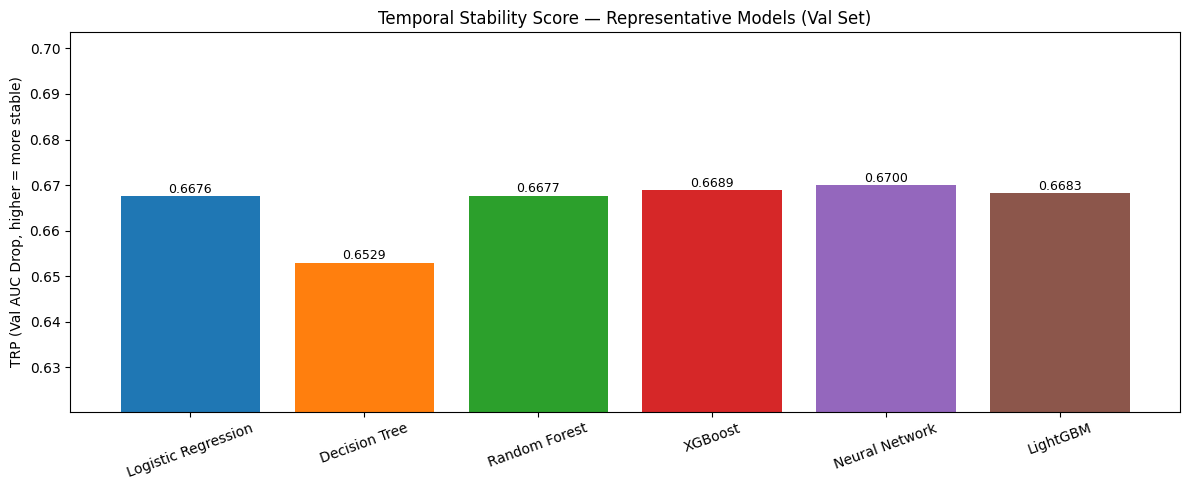

Saved: fig4_auc_drop_val.png


In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── Figure 1: Temporal Stability Score (TRP) per family — Val Set ──
family_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network', 'LightGBM']
family_colors = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree':       '#ff7f0e',
    'Random Forest':       '#2ca02c',
    'XGBoost':             '#d62728',
    'Neural Network':      '#9467bd',
    'LightGBM':            '#8c564b',
}

def infer_family(name):
    n = name.upper()
    if 'LR' in n:                    return 'Logistic Regression'
    if 'DTREE' in n or 'DT' in n:   return 'Decision Tree'
    if 'RF' in n:                    return 'Random Forest'
    if 'XGB' in n:                   return 'XGBoost'
    if 'NN' in n:                    return 'Neural Network'
    if 'LGBM' in n:                  return 'LightGBM'
    return 'Other'

# Best val_auc_drop per family (val set)
best_trp = {}
for name, res in all_results.items():
    fam = infer_family(name)
    trp = res['val_auc_drop']
    if fam not in best_trp or trp > best_trp[fam]:
        best_trp[fam] = trp

labels_trp = [f for f in family_order if f in best_trp]
values_trp = [best_trp[f] for f in labels_trp]
colors_trp = [family_colors[f] for f in labels_trp]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels_trp, values_trp, color=colors_trp)
for bar, val in zip(bars, values_trp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(min(values_trp) * 0.95, max(values_trp) * 1.05)
ax.set_ylabel('TRP (Val AUC Drop, higher = more stable)')
ax.set_title('Temporal Stability Score — Representative Models (Val Set)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig4_auc_drop_val.png', dpi=150)
plt.show()
print('Saved: fig4_auc_drop_val.png')


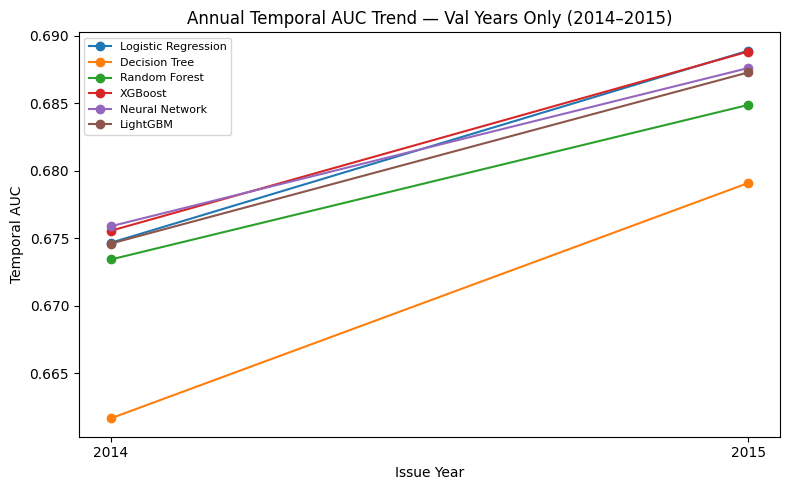

Saved: fig5_auc_over_time_val.png


In [39]:
# Figure 2: Annual Temporal AUC Trend — Val Set Only (2014-2015)

VAL_YEARS = [2014, 2015]

best_model_per_family = {}
for name, res in all_results.items():
    fam = infer_family(name)
    trp = res['val_auc_drop']
    if fam not in best_model_per_family or trp > best_model_per_family[fam][1]:
        best_model_per_family[fam] = (name, trp)

FAIR_MODELS_PLOT = [best_model_per_family[f][0] for f in family_order if f in best_model_per_family]
FAIR_LABELS_PLOT = [f for f in family_order if f in best_model_per_family]

fig, ax = plt.subplots(figsize=(8, 5))
for mname, family_label in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT):
    year_map = all_results[mname]['yearly']
    years = [y for y in sorted(year_map.keys()) if y in VAL_YEARS]
    vals  = [year_map[y] for y in years]
    ax.plot(years, vals, marker='o', label=family_label, color=family_colors[family_label])

ax.set_xlabel('Issue Year')
ax.set_ylabel('Temporal AUC')
ax.set_title('Annual Temporal AUC Trend — Val Years Only (2014–2015)')
ax.set_xticks(VAL_YEARS)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/fig5_auc_over_time_val.png', dpi=150)
plt.show()
print('Saved: fig5_auc_over_time_val.png')

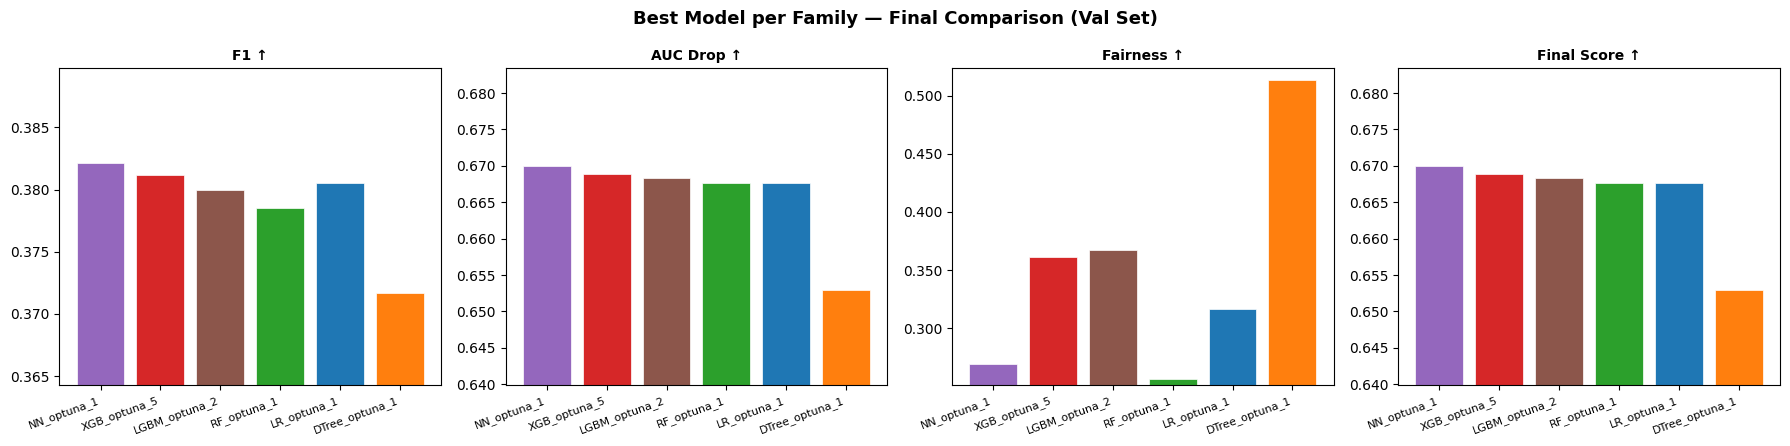

Saved: slide_fig1_best_model_per_family_val.png


In [40]:
# Figure 3: Best Model per Family — Final Comparison (Val Set)
# 4-panel: F1, AUC Drop (TRP), Fairness, Finals Score

REPRESENTATIVE_MODELS = [best_model_per_family[f][0] for f in family_order if f in best_model_per_family]

plot_df_final = df_ranked_sc[df_ranked_sc['Model'].isin(REPRESENTATIVE_MODELS)].copy()
plot_df_final['Family'] = plot_df_final['Model'].apply(infer_family)
# fairness violation = lower is better (invert of _fair_norm)
plot_df_final['_fair_norm_r'] = 1 - plot_df_final['_fair_norm']

bar_colors = [family_colors.get(f, '#9467bd') for f in plot_df_final['Family']]
x_labels   = plot_df_final['Model'].astype(str).tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Best Model per Family — Final Comparison (Val Set)', fontsize=13, fontweight='bold')

metrics = [
    ('Val F1',       'F1 ↑',                  True,  '%.4f'),
    ('Val AUC Drop', 'AUC Drop ↑',             True,  '%.4f'),
    ('_fair_norm', 'Fairness ↑',   True, '%.4f'),
    ('Final Score',  'Final Score ↑',      True,  '%.4f'),
]

for ax, (col, title, higher_better, fmt) in zip(axes, metrics):
    vals = plot_df_final[col].tolist()
    ax.bar(range(len(x_labels)), vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
    min_val = min(vals)
    max_val = max(vals)
    ax.set_ylim(min_val * 0.98, max_val * 1.02)

plt.tight_layout()
plt.savefig('/content/slide_fig1_best_model_per_family_val.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: slide_fig1_best_model_per_family_val.png')
